In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
os.makedirs("/content/charts", exist_ok=True)

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv

Dataset shape : (7043, 21)

Column dtypes :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

First 10 rows :
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMet

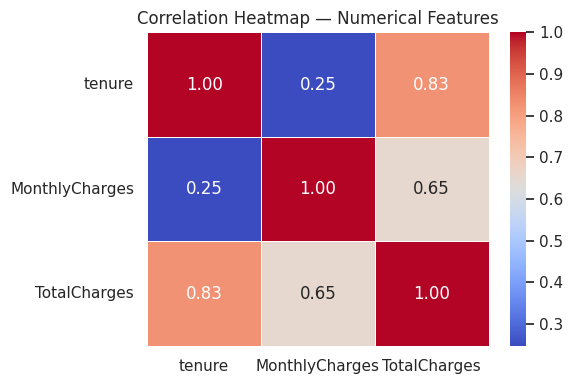

In [6]:
#DATA LOADING and EXPLORATORY ANALYSIS
from google.colab import files
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]

df = pd.read_csv(csv_name)

#Shape, dtypes, first 10 rows
print(f"\nDataset shape : {df.shape}")
print(f"\nColumn dtypes :\n{df.dtypes}")
print(f"\nFirst 10 rows :\n{df.head(10).to_string()}")

#Target column and class imbalance
print(f"\nChurn value counts:\n{df['Churn'].value_counts()}")
print(f"Churn rate : {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

#Missing or null values
print(f"\nNull values per column:\n{df.isnull().sum()}")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nAfter coercing TotalCharges — nulls: {df['TotalCharges'].isnull().sum()}")
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

#Summary
print(f"\nSummary statistics:\n{df[['tenure','MonthlyCharges','TotalCharges']].describe()}")

#Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 4))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, linewidths=0.5)
ax.set_title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.savefig("/content/charts/correlation_heatmap.png", dpi=150)
plt.show()

In [7]:
df_model = df.copy()

#Drop customerID (not predictive)
df_model.drop(columns=['customerID'], inplace=True)

#Encode target
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

#Encode categoricals - Label Encoding for binary cols,
#One-Hot Encoding for multi-class cols.
#LabelEncoding for binary avoids dimensionality explosion;
#One-Hot for multi-class avoids false ordinal relationships.
binary_cols = [c for c in df_model.select_dtypes('object').columns
               if df_model[c].nunique() == 2]
multi_cols  = [c for c in df_model.select_dtypes('object').columns
               if df_model[c].nunique() > 2]

le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model = pd.get_dummies(df_model, columns=multi_cols, drop_first=True)

print(f"Shape after encoding : {df_model.shape}")

#Feature Engineering — 2 new features
df_model['ChargesPerMonth'] = df_model['TotalCharges'] / (df_model['tenure'] + 1)

#SeniorWithNoSupport: SeniorCitizen==1 AND TechSupport=="No"
#After encoding, TechSupport_No = 1 where TechSupport was "No"
tech_no_col = [c for c in df_model.columns if 'TechSupport' in c and 'No' in c]
if tech_no_col:
    df_model['SeniorWithNoSupport'] = (
        (df_model['SeniorCitizen'] == 1) & (df_model[tech_no_col[0]] == 1)
    ).astype(int)
else:
    df_model['SeniorWithNoSupport'] = 0

print("New features added: ChargesPerMonth, SeniorWithNoSupport")

#Scale numerical features
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth']
scaler = StandardScaler()
df_model[scale_cols] = scaler.fit_transform(df_model[scale_cols])

#Train / test split - stratified 80/20
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Churn rate — train: {y_train.mean()*100:.2f}%  |  test: {y_test.mean()*100:.2f}%")


Shape after encoding : (7043, 31)
New features added: ChargesPerMonth, SeniorWithNoSupport
Train size: 5634  |  Test size: 1409
Churn rate — train: 26.54%  |  test: 26.54%



Logistic Regression:
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1035
           1       0.68      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409


XGBoost:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.59      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.77   

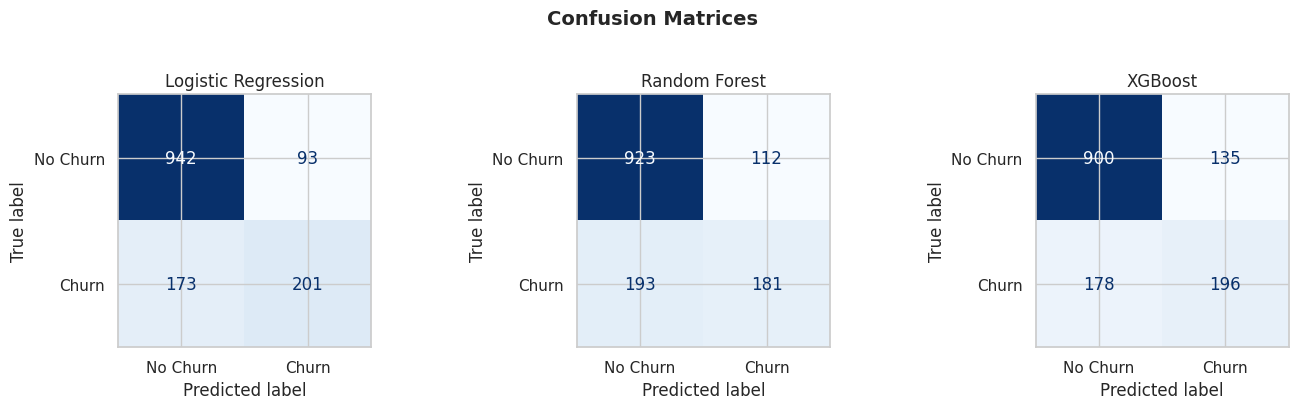

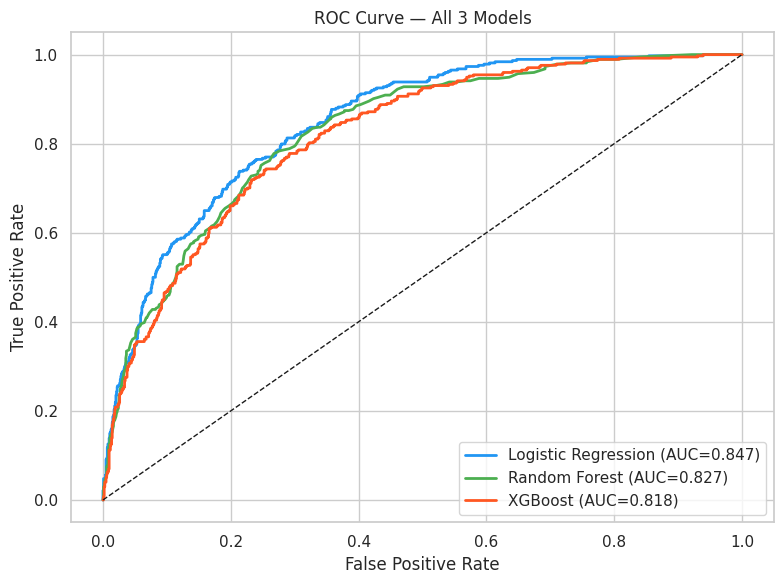


Best model by ROC-AUC: Logistic Regression

Running GridSearchCV on Logistic Regression …
Best params : {'C': 10, 'penalty': 'l2'}
Best CV AUC : 0.8487


LogisticRegression(C=10, max_iter=1000, random_state=42)

In [10]:
#Model training
#Defining the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42,
                                         verbosity=0),
}

results   = {}
roc_data  = {}
cms        = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
    }
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)
    cms[name]      = confusion_matrix(y_test, y_pred)
    print(f"\n{name}:\n{classification_report(y_test, y_pred)}")

#Metrics table
results_df = pd.DataFrame(results).T.round(4)
print("\n── Model Comparison Table ──")
print(results_df.to_string())

#Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, cm) in zip(axes, cms.items()):
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.suptitle("Confusion Matrices", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("/content/charts/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

#ROC curves
colors = ["#2196F3", "#4CAF50", "#FF5722"]
fig, ax = plt.subplots(figsize=(8, 6))
for (name, (fpr, tpr)), color in zip(roc_data.items(), colors):
    auc = results[name]["ROC-AUC"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=2)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — All 3 Models")
ax.legend()
plt.tight_layout()
plt.savefig("/content/model_comparison.png", dpi=150)
plt.show()

#Best model selection
best_model_name = results_df["ROC-AUC"].idxmax()
best_model      = models[best_model_name]
print(f"\nBest model by ROC-AUC: {best_model_name}")

#Hyperparameter tuning on best model
print(f"\nRunning GridSearchCV on {best_model_name} …")
if best_model_name == "Random Forest":
    param_grid = {
        "n_estimators": [100, 200],
        "max_depth":    [None, 10, 20],
        "min_samples_split": [2, 5],
    }
    tuner = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
    )
elif best_model_name == "XGBoost":
    param_grid = {
        "n_estimators":  [100, 200],
        "max_depth":     [3, 5, 7],
        "learning_rate": [0.05, 0.1],
    }
    tuner = GridSearchCV(
        XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                      random_state=42, verbosity=0),
        param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
    )
else:  # Logistic Regression
    param_grid = {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"]}
    tuner = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
    )

tuner.fit(X_train, y_train)
best_tuned = tuner.best_estimator_
print(f"Best params : {tuner.best_params_}")
print(f"Best CV AUC : {tuner.best_score_:.4f}")

#Best_model to tuned version
best_model = best_tuned
best_model.fit(X_train, y_train)



Customers per risk tier:
Risk_Tier
Low Risk       4995
Medium Risk    1501
High Risk       547
Name: count, dtype: int64

Tier statistics:
             Avg_MonthlyCharges  Avg_Tenure  Count
Risk_Tier                                         
High Risk                 82.15        4.01    547
Low Risk                  59.17       40.17   4995
Medium Risk               77.02       16.75   1501

Contract distribution by tier:
     Risk_Tier        Contract  Count
0    High Risk  Month-to-month    547
1     Low Risk  Month-to-month   1839
2     Low Risk        One year   1461
3     Low Risk        Two year   1695
4  Medium Risk  Month-to-month   1489
5  Medium Risk        One year     12


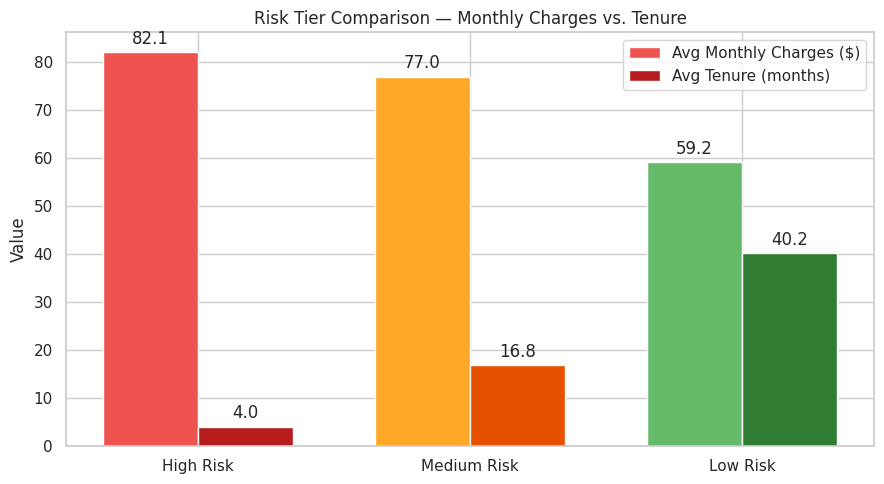

In [11]:
#CUSTOMER RISK SEGMENTATION
#Churn probabilities from best tuned model on FULL dataset
df_seg = df.copy()
df_seg['Churn_Binary'] = (df_seg['Churn'] == 'Yes').astype(int)

all_proba = best_model.predict_proba(X)[:, 1]

df_seg = df_seg.reset_index(drop=True)
df_seg['Churn_Prob'] = all_proba

#Segment into tiers
def assign_tier(p):
    if p >= 0.70:   return "High Risk"
    elif p >= 0.40: return "Medium Risk"
    else:           return "Low Risk"

df_seg['Risk_Tier'] = df_seg['Churn_Prob'].apply(assign_tier)

tier_counts = df_seg['Risk_Tier'].value_counts()
print(f"\nCustomers per risk tier:\n{tier_counts}")

#Per-tier stats
tier_stats = df_seg.groupby('Risk_Tier').agg(
    Avg_MonthlyCharges=('MonthlyCharges', 'mean'),
    Avg_Tenure=('tenure', 'mean'),
    Count=('Risk_Tier', 'count')
).round(2)
print(f"\nTier statistics:\n{tier_stats}")

#Contract distribution per tier
contract_dist = (df_seg.groupby(['Risk_Tier', 'Contract'])
                        .size()
                        .reset_index(name='Count'))
print(f"\nContract distribution by tier:\n{contract_dist}")

#Grouped bar chart - avg MonthlyCharges & avg Tenure by tier
tier_order  = ["High Risk", "Medium Risk", "Low Risk"]
tier_colors = ["#EF5350", "#FFA726", "#66BB6A"]

tier_plot = df_seg.groupby('Risk_Tier').agg(
    MonthlyCharges=('MonthlyCharges', 'mean'),
    tenure=('tenure', 'mean')
).reindex(tier_order)

x   = np.arange(len(tier_order))
w   = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, tier_plot['MonthlyCharges'], width=w,
            label='Avg Monthly Charges ($)', color=tier_colors)
b2 = ax.bar(x + w/2, tier_plot['tenure'], width=w,
            label='Avg Tenure (months)', color=['#B71C1C','#E65100','#2E7D32'])
ax.set_xticks(x)
ax.set_xticklabels(tier_order)
ax.set_ylabel("Value")
ax.set_title("Risk Tier Comparison — Monthly Charges vs. Tenure")
ax.legend()
ax.bar_label(b1, fmt='%.1f', padding=3)
ax.bar_label(b2, fmt='%.1f', padding=3)
plt.tight_layout()
plt.savefig("/content/charts/risk_tier_comparison.png", dpi=150)
plt.show()

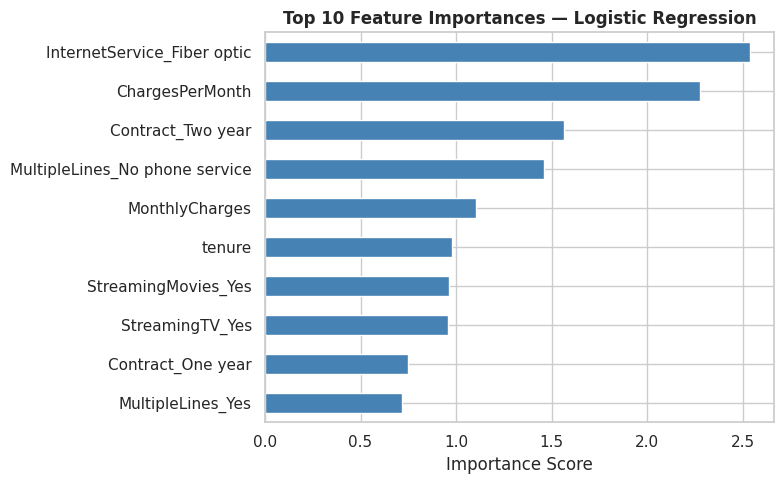

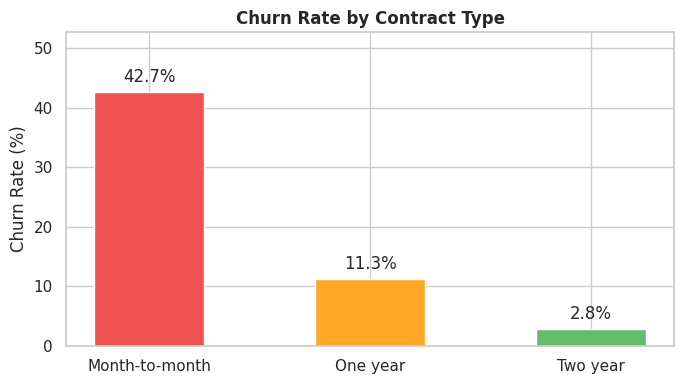

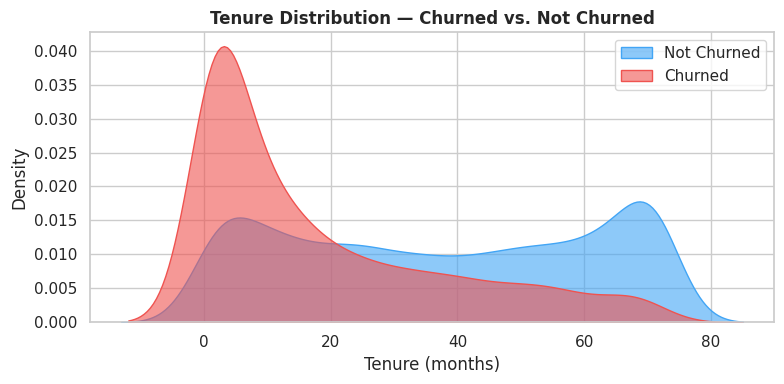

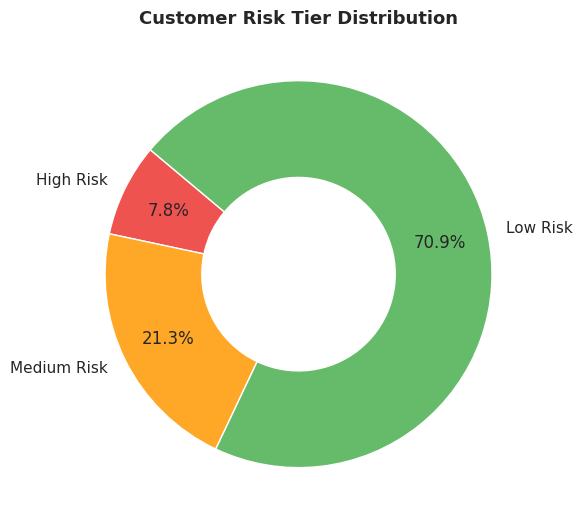

In [12]:
#Visualizations through charts
#Chart 1: Feature Importance (top 10)
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X.columns)
else:
    #Logistic Regression: use absolute coefficients
    fi = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)

top10 = fi.nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
top10.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f"Top 10 Feature Importances — {best_model_name}", fontweight='bold')
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("/content/charts/feature_importance.png", dpi=150)
plt.show()

#Chart 2: Churn Rate by Contract Type
contract_churn = (df.groupby('Contract')['Churn']
                    .apply(lambda x: (x == 'Yes').mean() * 100)
                    .reset_index(name='ChurnRate'))
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contract_churn['Contract'], contract_churn['ChurnRate'],
              color=['#EF5350','#FFA726','#66BB6A'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Contract Type", fontweight='bold')
ax.set_ylim(0, contract_churn['ChurnRate'].max() + 10)
plt.tight_layout()
plt.savefig("/content/charts/churn_by_contract.png", dpi=150)
plt.show()

#Chart 3: Tenure Distribution — Churned vs. Not Churned (KDE)
fig, ax = plt.subplots(figsize=(8, 4))
churn_yes = df[df['Churn'] == 'Yes']['tenure']
churn_no  = df[df['Churn'] == 'No']['tenure']
sns.kdeplot(churn_no,  ax=ax, fill=True, label='Not Churned', color='#42A5F5', alpha=0.6)
sns.kdeplot(churn_yes, ax=ax, fill=True, label='Churned',     color='#EF5350', alpha=0.6)
ax.set_xlabel("Tenure (months)")
ax.set_title("Tenure Distribution — Churned vs. Not Churned", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("/content/charts/tenure_distribution.png", dpi=150)
plt.show()

#Chart 4: Risk Tier Donut/Pie Chart
tier_c = df_seg['Risk_Tier'].value_counts().reindex(tier_order)
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    tier_c.values,
    labels=tier_c.index,
    colors=tier_colors,
    autopct='%1.1f%%',
    pctdistance=0.75,
    wedgeprops=dict(width=0.5),
    startangle=140,
)
for at in autotexts:
    at.set_fontsize(12)
ax.set_title("Customer Risk Tier Distribution", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("/content/charts/risk_tier_donut.png", dpi=150)
plt.show()

#Interactive Plotly Scatter - MonthlyCharges vs Tenure
fig_plotly = px.scatter(
    df_seg,
    x='tenure',
    y='MonthlyCharges',
    color='Churn',
    color_discrete_map={'Yes': '#EF5350', 'No': '#42A5F5'},
    opacity=0.6,
    title="Monthly Charges vs. Tenure — Colored by Churn",
    labels={'tenure': 'Tenure (months)', 'MonthlyCharges': 'Monthly Charges ($)'},
    hover_data=['Contract', 'Risk_Tier'],
    template='plotly_white',
)
fig_plotly.show()

In [16]:
#INSIGHTS & BUSINESS RECOMMENDATIONS

insights = f"""
BUSINESS INSIGHTS & RECOMMENDATIONS

1. BEST MODEL
   ▸ {best_model_name} achieved the highest ROC-AUC ({results_df.loc[best_model_name,'ROC-AUC']:.3f}),
     making it the best at distinguishing churners from loyal
     customers — the most important metric for imbalanced data.

2. TOP 3 CHURN DRIVERS (from feature importance)
   ▸ {top10.index[-1]}
   ▸ {top10.index[-2]}
   ▸ {top10.index[-3]}
   These features have the strongest signal for predicting churn.

3. HIGH RISK CUSTOMER PROFILE
   ▸ Predominantly on Month-to-Month contracts (no commitment).
   ▸ Higher average MonthlyCharges — price-sensitive segment.
   ▸ Short tenure — new customers who haven't seen long-term value.

4. ACTIONABLE BUSINESS RECOMMENDATIONS
   ▸ Retention Offer: Target High-Risk Month-to-Month customers
     with discounted 1-Year contract upgrades (e.g., 15–20% off).
     Locking them into a longer contract sharply reduces churn.
   ▸ Proactive Onboarding: The first 12 months have the highest
     churn risk. Launch a 3-touch onboarding program (month 1, 3,
     6) with personalised check-ins, feature tips, and loyalty
     credits to build early engagement.

5. MODEL LIMITATIONS & FUTURE IMPROVEMENTS
   ▸ Class imbalance (~27% churn) may bias predictions — SMOTE
     or class weighting could further improve recall on churners.
   ▸ No time-series data: churn triggers (billing disputes, service
     outages) are not captured — adding CRM event logs would help.
   ▸ Feature set is static; real-time scoring pipeline and monthly
     retraining would keep the model production-ready.
"""
print(insights)

#GENERATING requirements.txt
req_content = """pandas
numpy
scikit-learn
xgboost
matplotlib
seaborn
plotly
"""
with open("/content/requirements.txt", "w") as f:
    f.write(req_content)

#DOWNLOADING ALL OUTPUT FILES
import shutil, zipfile

zip_path = "/content/ChurnAnalysis_Outputs.zip"
with zipfile.ZipFile(zip_path, 'w') as zf:
    zf.write("/content/model_comparison.png",       "model_comparison.png")
    zf.write("/content/requirements.txt",            "requirements.txt")
    for chart in os.listdir("/content/charts"):
        zf.write(f"/content/charts/{chart}",        f"charts/{chart}")

files.download(zip_path)



BUSINESS INSIGHTS & RECOMMENDATIONS             
 
1. BEST MODEL
   ▸ Logistic Regression achieved the highest ROC-AUC (0.847),
     making it the best at distinguishing churners from loyal
     customers — the most important metric for imbalanced data.
 
2. TOP 3 CHURN DRIVERS (from feature importance)
   ▸ InternetService_Fiber optic
   ▸ ChargesPerMonth
   ▸ Contract_Two year
   These features have the strongest signal for predicting churn.
 
3. HIGH RISK CUSTOMER PROFILE
   ▸ Predominantly on Month-to-Month contracts (no commitment).
   ▸ Higher average MonthlyCharges — price-sensitive segment.
   ▸ Short tenure — new customers who haven't seen long-term value.
 
4. ACTIONABLE BUSINESS RECOMMENDATIONS
   ▸ Retention Offer: Target High-Risk Month-to-Month customers
     with discounted 1-Year contract upgrades (e.g., 15–20% off).
     Locking them into a longer contract sharply reduces churn.
   ▸ Proactive Onboarding: The first 12 months have the highest
     churn risk. Launch a 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>